# Health, Habits, and Cancer: Examining Risk of Cancer Using Support Vector Machines 

## Import necessary libraries

In [81]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots, cm
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import sklearn.model_selection as skm
from sklearn.model_selection import train_test_split, GridSearchCV
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay
roc_curve = RocCurveDisplay.from_estimator

## Load data and generate DataFrame

In [54]:
health = pd.read_csv("C:/Users/jacob/Downloads/nhis_2022.csv")
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35115 entries, 0 to 35114
Data columns (total 48 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         35115 non-null  int64  
 1   SERIAL       35115 non-null  int64  
 2   STRATA       35115 non-null  int64  
 3   PSU          35115 non-null  int64  
 4   NHISHID      35115 non-null  object 
 5   REGION       35115 non-null  int64  
 6   PERNUM       35115 non-null  int64  
 7   NHISPID      35115 non-null  object 
 8   HHX          35115 non-null  object 
 9   SAMPWEIGHT   35115 non-null  float64
 10  ASTATFLG     35115 non-null  int64  
 11  CSTATFLG     35115 non-null  int64  
 12  AGE          35115 non-null  int64  
 13  SEX          35115 non-null  int64  
 14  MARSTCUR     35115 non-null  int64  
 15  EDUC         35115 non-null  int64  
 16  HOURSWRK     35115 non-null  int64  
 17  POVERTY      35115 non-null  int64  
 18  HEIGHT       35115 non-null  int64  
 19  WEIG

### Preparing Target Variable

The chosen target variable for this analysis is CANCEREV, with respondents either having or not having cancer represented by either 2's or 1's respectively. The remaining values represent a lack of response or the question not being asked to specific respondents (i.e. children). This variable will be cleaned to remove these non-responses and a new variable CANCER is made to adjust the remaining values to a binary format.

In [55]:
# determine value counts for CANCEREV variable
health['CANCEREV'].value_counts(dropna=False).sort_index() 

CANCEREV
0     7464
1    24184
2     3430
7       28
9        9
Name: count, dtype: int64

In [56]:
health = health[health['CANCEREV'].isin([1, 2])].copy() # remove 0s, 7s, and 9s from CANCEREV column
health['CANCER'] = (health['CANCEREV'] == 2).astype(int) # convert to binary format

In [57]:
health['CANCER'].value_counts(dropna=False).sort_index() # verify binary format

CANCER
0    24184
1     3430
Name: count, dtype: int64

Lastly, the remaining disease columns will be dropped so as to not interfere with the CANCER variable.

In [58]:
health = health.drop(columns=["CHEARTDIEV", "DIABETICEV", "HEARTATTEV", "STROKEV"])

### Preparing Predictor Variables

The primary predictor variables of interest that will be considered are age (AGE), ratio of family income to poverty threshold (POVERTY), body mass index (BMICALC), health insurance coverage status (HINOTCOVE), frequency drank alcohol in past year in number of units (ALCANYNO), duration of moderate activity lasting longer than 10 minutes (MOD10DMIN), and usual hours of sleep per day (HRSLEEP). 

Given that one of the variables considered concerns alcohol consumption, the data is filtered to only consider respondents of 21 years of age or above. 

In [59]:
health = health[health["AGE"] >= 21].copy()
health = health[health["REGION"] == 3].copy()

Next, each predictor variable is inspected for sentinel values that will need to be removed prior to analysis. Each sentinel value is converted to a null value which are then collectively removed from the DataFrame.

In [60]:
predictors = ['AGE', 'POVERTY', 'BMICALC', 'HINOTCOVE', 'ALCANYNO', 'MOD10DMIN', 'HRSLEEP']

for predictor in predictors:
    print(f"\n{predictor}:")
    print(health[predictor].value_counts(dropna=False).sort_index())


AGE:
AGE
21      85
22      95
23     115
24     112
25     129
      ... 
83      72
84      73
85     364
997     22
999      2
Name: count, Length: 67, dtype: int64

POVERTY:
POVERTY
11     315
12     361
13     490
21     513
22     521
23     405
24     529
31     905
32     733
33     637
34     615
35     524
36     558
37    2843
Name: count, dtype: int64

BMICALC:
BMICALC
15.2       1
15.4       1
16.3       1
16.5       1
16.6       2
        ... 
49.2       1
50.8       1
51.9       1
52.3       1
996.0    854
Name: count, Length: 314, dtype: int64

HINOTCOVE:
HINOTCOVE
1    8868
2    1054
9      27
Name: count, dtype: int64

ALCANYNO:
ALCANYNO
0      2043
1      1770
2      1713
3       894
4       465
5       400
6       189
7       414
8        31
9         9
10      116
11        2
12       69
14        7
15       33
16        3
17        1
20       30
21        1
24       12
25        7
26        5
28        1
30       33
35        1
36        2
40        5
45        1

In [61]:
health['AGE'] = health['AGE'].replace([997, 999], np.nan)
health['BMICALC'] = health['BMICALC'].replace(996.0, np.nan)
health['HINOTCOVE'] = health['HINOTCOVE'].replace(9, np.nan).map({1: 1, 2: 0}) # mapping insurance coverage to binary format
health['ALCANYNO'] = health['ALCANYNO'].replace([996, 997, 998, 999], np.nan)
health['MOD10DMIN'] = health['MOD10DMIN'].replace([996, 997, 998, 999], np.nan)
health['HRSLEEP'] = health['HRSLEEP'].replace([97, 98, 99], np.nan)

In [62]:
health = health[predictors + ['CANCER']].dropna() # drop all null values from DataFrame 

In [63]:
health.isna().sum() # verify lack of null values

AGE          0
POVERTY      0
BMICALC      0
HINOTCOVE    0
ALCANYNO     0
MOD10DMIN    0
HRSLEEP      0
CANCER       0
dtype: int64

In [64]:
health.shape

(7571, 8)

## Exploratory Data Analysis

The relationships between the predicor variables and the target variable are further examined using correlation matrices and scatter plots.

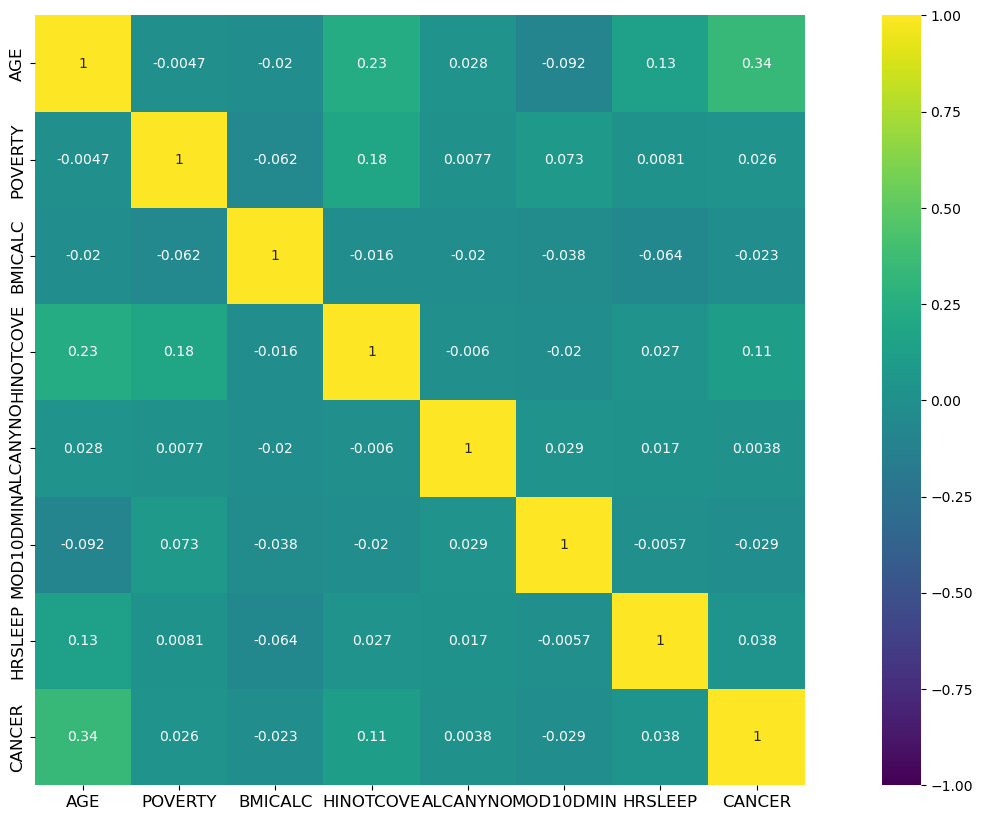

In [121]:
corr_matrix = health[predictors + ['CANCER']].corr()

plt.figure(figsize=(20,10))

sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap='viridis'
)

plt.tick_params(labelsize=12)

plt.show()

The correlation matrix above conveys that the two variable with the greatest correlation coefficients relative to the target variable of CANCER are age (AGE) and whether they have health insurance coverage (HINOTCOVE).

This plot below examines the relationship between age and body mass index, with data points colored based on which of the cancer classes they belong to -- 'no cancer' in blue, 'cancer' in red.

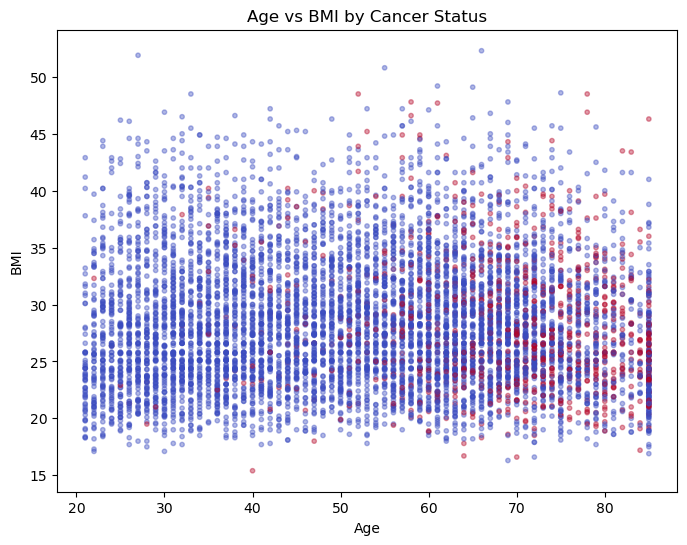

In [111]:
plt.figure(figsize=(8, 6))
plt.scatter(health['AGE'], health['BMICALC'],
            c=health['CANCER'], cmap='coolwarm', alpha=0.4, s=10)
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI by Cancer Status')
plt.show()

The bar plot below examines the rate of cancer diagnosis across various income levels. 

<Axes: xlabel='POVERTY'>

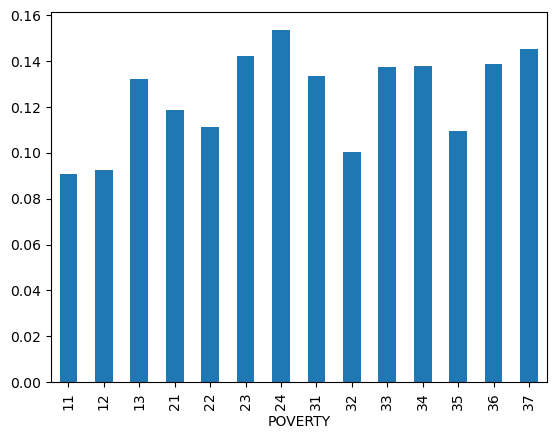

In [128]:
health.groupby('POVERTY')['CANCER'].mean().plot(kind='bar')

Based on the output, the rate of cancer occurrence has no clear pattern across the income statuses, but there is noticeably lower rates in the lowest income groups (closer to the poverty line).

The KDE plot below provides two curves for the density of cancer status relative to age (no cancer in blue and cancer in orange).

CANCER
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: AGE, dtype: object

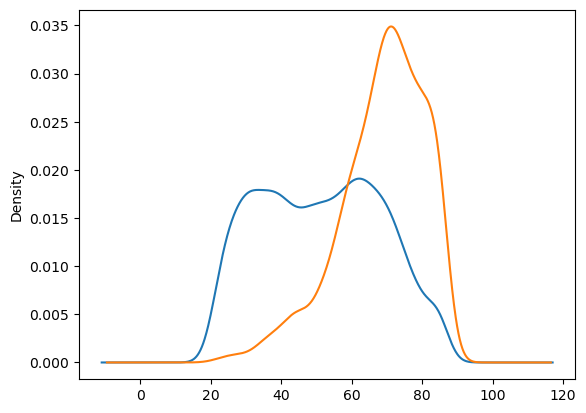

In [130]:
health.groupby('CANCER')['AGE'].plot(kind='kde')

Based on the curves, like with the correlation matrix, the occurrence of cancer appears to be most dense between ages of 60 and 90.

## Support Vector Machine with Linear Kernel

The code below first defines the predictor and target variables before splitting the dataset into training and test sets representing 80 and 20% of data points, respectively. A support vector machine with a linear kernel is then fit to the training data. Using cross-validation, the optimal hyperparameters are determined and used to generate an optimal model.

In [65]:
# define predictor variables and target variable
X = health[predictors]
y = health['CANCER']

In [66]:
# split the data between test and train
# stratify applied to ensure train and test sets have same class breakdown as original data
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    train_size=0.8,
                                                    random_state=1,
                                                    stratify=y)

In [91]:
# fit SVM with linear kernel
svm_linear = SVC(kernel='linear', class_weight='balanced') # balanced argument to account for class imbalance
svm_linear.fit(X_train, y_train)

# 5-fold cross-validation along with grid search across 5 different cost values
kfold = skm.KFold(5, 
                  random_state=0,
                  shuffle=True)
grid_linear = skm.GridSearchCV(svm_linear,
                        {'C':[0.01,0.1,1,5,10]}, # potential cost values
                        refit=True,
                        cv=kfold,
                        scoring='roc_auc',
                        n_jobs=-1) # roc_auc scoring to ensure model doesn't bias to majority class
grid_linear.fit(X_train, y_train)
grid_linear.best_params_

{'C': 5}

In [94]:
# support points
svm_linear.n_support_.sum()

np.int64(3806)

The code blocks below will generate training and test errors for both the untuned and tuned linear kernel models.

In [95]:
# training error rate
y_pred_linear = svm_linear.predict(X_train)
training_error_linear = np.mean(y_pred_linear != y_train)
# test error rate
y_pred_test_linear = svm_linear.predict(X_test)
test_error_linear = np.mean(y_pred_test_linear != y_test)
training_error_linear, test_error_linear

(np.float64(0.3513870541611625), np.float64(0.3465346534653465))

In [96]:
# training error rate
y_pred_linear2 = grid_linear.predict(X_train)
training_error_linear2 = np.mean(y_pred_linear2 != y_train)
# test error rate
y_pred_test_linear2 = grid_linear.predict(X_test)
test_error_linear2 = np.mean(y_pred_test_linear2 != y_test)
training_error_linear2, test_error_linear2

(np.float64(0.34775429326287977), np.float64(0.3372937293729373))

The tuned model appears to have very subtle accuracy improvements. A comparison of the ROC curves between the training and test data for this model is shown below.

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


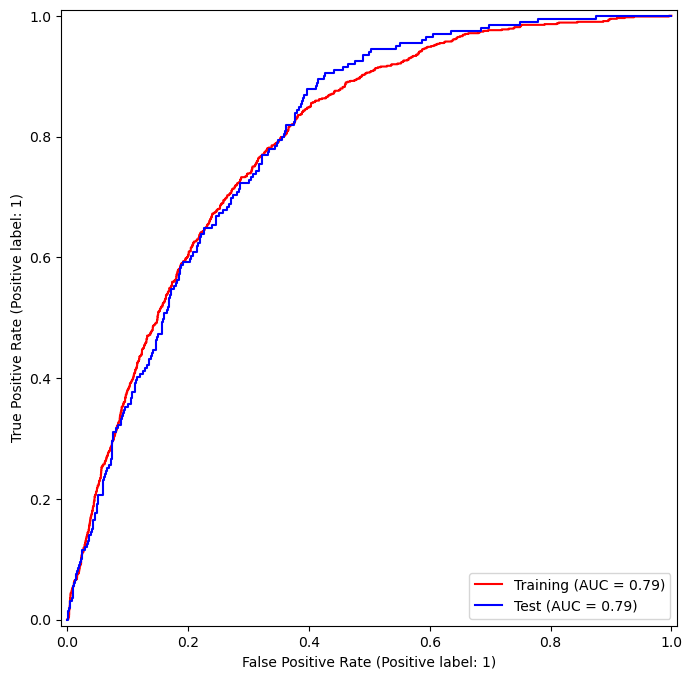

In [100]:
fig, ax = subplots(figsize=(8,8))
roc_curve(grid_linear,
          X_train,
          y_train,
          name='Training',
          color='r',
          ax=ax);
roc_curve(grid_linear,
          X_test,
          y_test,
          name='Test',
          color='b',
          ax=ax);

The following code generates a support vector classifier examining only two predictors (age and BMI) in order to visualize the decision boundary and margins used by the linear kernel model. 

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


KeyError: '[5, 9, 11, 13, 14, 19, 20, 21, 22, 25, 26, 27, 28, 29, 30, 31, 34, 36, 38, 40, 41, 43, 46, 48, 51, 52, 59, 64, 67, 68, 71, 73, 76, 80, 82, 83, 84, 87, 89, 91, 94, 100, 101, 102, 103, 105, 108, 110, 111, 116, 117, 121, 124, 126, 129, 132, 135, 137, 143, 144, 148, 150, 158, 161, 162, 164, 166, 172, 173, 174, 175, 177, 180, 181, 183, 192, 193, 195, 199, 200, 202, 205, 206, 207, 209, 211, 212, 213, 223, 225, 226, 228, 231, 232, 233, 234, 235, 236, 237, 239, 240, 249, 252, 254, 255, 256, 258, 259, 263, 265, 266, 267, 268, 273, 275, 277, 280, 292, 295, 297, 299, 302, 303, 304, 305, 306, 308, 311, 312, 313, 319, 327, 329, 330, 331, 332, 334, 336, 337, 338, 341, 345, 347, 348, 349, 350, 356, 359, 360, 361, 363, 366, 371, 377, 378, 379, 380, 381, 384, 390, 392, 394, 395, 397, 401, 403, 404, 406, 410, 411, 415, 416, 417, 419, 421, 425, 428, 430, 432, 436, 438, 439, 440, 441, 442, 444, 447, 448, 449, 451, 452, 456, 460, 463, 465, 466, 468, 469, 470, 471, 477, 478, 479, 480, 482, 484, 4

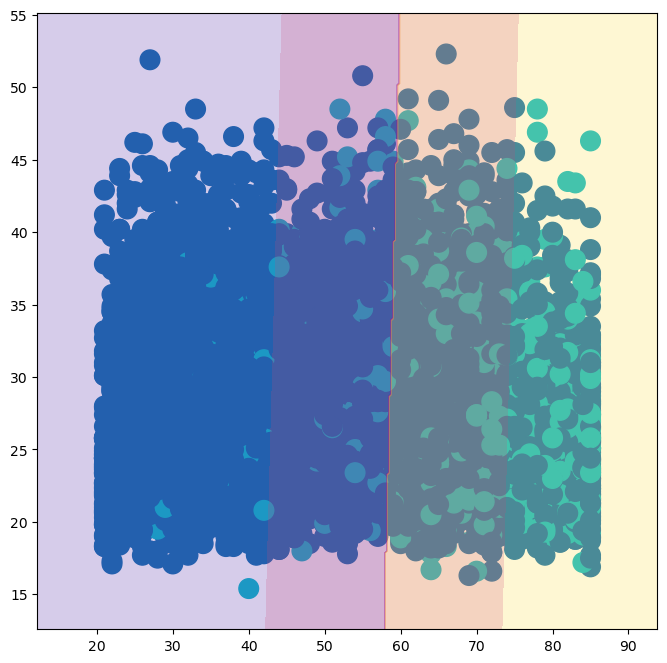

In [114]:
# 2 feature model for visualization purposes only
predictors2 = ['AGE', 'BMICALC']
X2 = health[predictors2]
y2 = health['CANCER']

svm_linear_2 = SVC(kernel='linear', 
                    class_weight='balanced',
                    C=grid_linear.best_params_['C'])
svm_linear_2.fit(X2, y2)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X2, y2, svm_linear_2, ax=ax)
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI with Decision Boundary for Cancer Class')

From the ROC curves, the model appears to be consistent with handling both training and test data and does not broadly overfit the training data. The decision boundary plot shows that age is more correlated with cancer class compared to BMI, with a majority of cancer cases occurring with higher ages.

## Support Vector Machine with Radial Kernel

In [101]:
# fit SVM with radial kernel
svm_radial = SVC(kernel='rbf', class_weight='balanced') 
svm_radial.fit(X_train, y_train)

# 5-fold cross-validation along with grid search across multiple values of cost and gamma
kfold = skm.KFold(5, 
                  random_state=0,
                  shuffle=True)
grid_radial = skm.GridSearchCV(svm_radial,
                        {'C':[0.01,0.1,1,5,10],
                        'gamma':[0.0001,0.001,0.01,0.1,1]},
                        refit=True,
                        cv=kfold,
                        scoring='roc_auc',
                        n_jobs=-1)
grid_radial.fit(X_train, y_train)
grid_radial.best_params_

{'C': 1, 'gamma': 0.0001}

In [102]:
# support points
svm_radial.n_support_.sum()

np.int64(3848)

The code blocks below will generate training and test errors for both the untuned and tuned radial kernel models.

In [103]:
# training error rate
y_pred_radial = svm_radial.predict(X_train)
training_error_radial = np.mean(y_pred_radial != y_train)
# test error rate
y_pred_test_radial = svm_radial.predict(X_test)
test_error_radial = np.mean(y_pred_test_radial != y_test)
training_error_radial, test_error_radial

(np.float64(0.3690554821664465), np.float64(0.3801980198019802))

In [104]:
# training error rate
y_pred_radial2 = grid_radial.predict(X_train)
training_error_radial2 = np.mean(y_pred_radial2 != y_train)
# test error rate
y_pred_test_radial2 = grid_radial.predict(X_test)
test_error_radial2 = np.mean(y_pred_test_radial2 != y_test)
training_error_radial2, test_error_radial2

(np.float64(0.3667437252311757), np.float64(0.37557755775577556))

The tuned radial model appears to have very slight improvements in accuracy. A comparison of the ROC curves between the training and test data for this model is shown below.

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


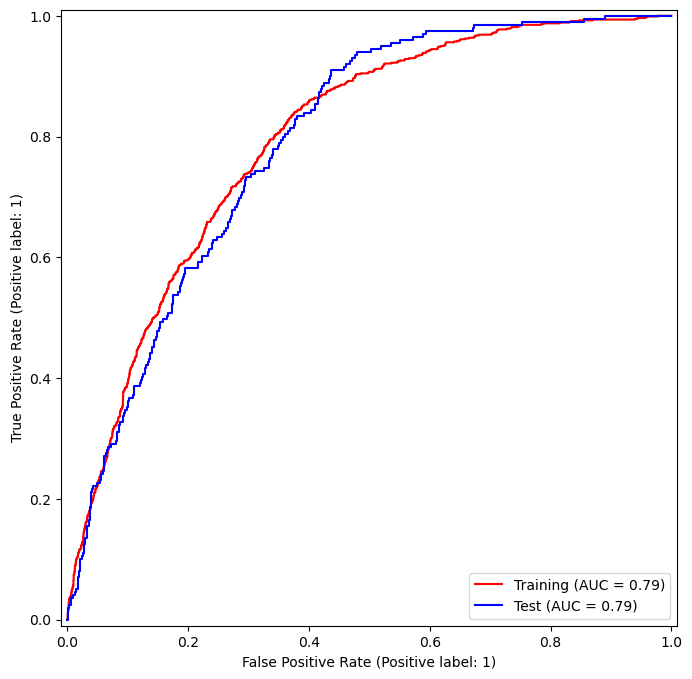

In [105]:
fig, ax = subplots(figsize=(8,8))
roc_curve(grid_radial,
          X_train,
          y_train,
          name='Training',
          color='r',
          ax=ax);
roc_curve(grid_radial,
          X_test,
          y_test,
          name='Test',
          color='b',
          ax=ax);

The following code again generates a support vector classifier examining only two predictors (age and BMI) to visualize the decision boundary and margins used by the radial kernel model. 

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


KeyError: '[0, 5, 9, 11, 13, 14, 19, 20, 21, 22, 25, 26, 27, 28, 29, 30, 31, 34, 36, 38, 40, 41, 43, 46, 48, 51, 52, 59, 64, 67, 68, 71, 73, 76, 80, 82, 83, 84, 87, 89, 91, 94, 100, 101, 102, 103, 105, 108, 110, 111, 116, 117, 121, 124, 126, 129, 132, 135, 137, 143, 144, 148, 150, 158, 161, 162, 164, 166, 172, 173, 174, 175, 177, 180, 181, 183, 192, 193, 195, 199, 200, 202, 205, 206, 207, 209, 212, 213, 223, 225, 226, 228, 231, 232, 233, 234, 235, 236, 237, 239, 240, 249, 252, 254, 255, 256, 258, 259, 263, 265, 266, 267, 268, 273, 275, 277, 280, 292, 295, 297, 299, 302, 303, 304, 305, 306, 308, 311, 312, 313, 319, 327, 329, 330, 331, 332, 334, 336, 337, 338, 341, 345, 347, 348, 349, 350, 356, 359, 360, 361, 363, 366, 371, 377, 378, 379, 380, 381, 384, 390, 392, 394, 395, 397, 401, 403, 404, 406, 410, 411, 415, 416, 417, 419, 421, 425, 428, 430, 432, 436, 438, 439, 440, 441, 442, 444, 447, 448, 449, 451, 452, 456, 460, 463, 465, 466, 468, 469, 470, 471, 477, 478, 479, 480, 482, 484, 485

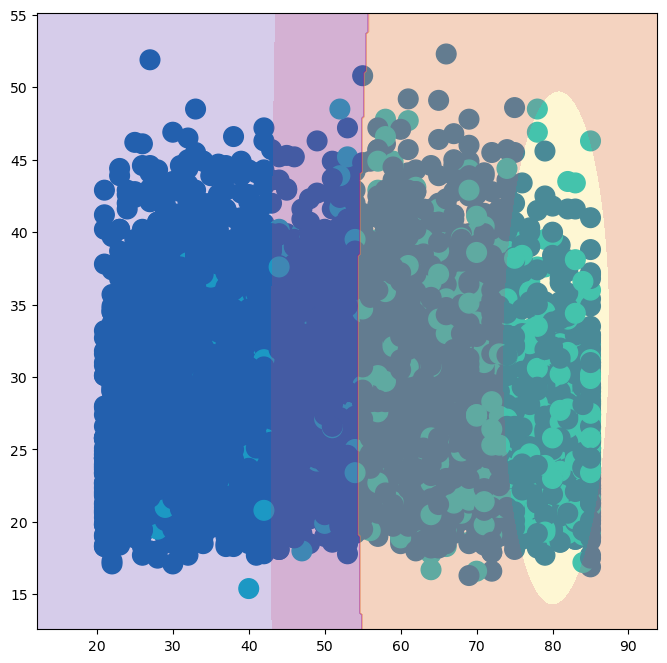

In [115]:
# 2 feature model for visualization purposes only
predictors2 = ['AGE', 'BMICALC']
X2 = health[predictors2]
y2 = health['CANCER']

svm_radial_2 = SVC(kernel='rbf', 
                    class_weight='balanced',
                    C=grid_radial.best_params_['C'],
                    gamma=grid_radial.best_params_['gamma'])
svm_radial_2.fit(X2, y2)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X2, y2, svm_radial_2, ax=ax)
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI with Decision Boundary for Cancer Class')

From the ROC curves, the radial model also appears to be consistent with handling both training and test data. The decision boundary plot shows that age is more correlated with cancer class compared to BMI, again with the data points classified as cancer falling toward higher ages.

## Support Vector Machine with Polynomial Kernel

In [106]:
# fit SVM with polynomial kernel
svm_poly = SVC(kernel='poly', class_weight='balanced') 
svm_poly.fit(X_train, y_train)

# 5-fold cross-validation along with grid search across multiple values of cost and degree
kfold = skm.KFold(5, 
                  random_state=0,
                  shuffle=True)
grid_poly = skm.GridSearchCV(svm_poly,
                        {'C':[0.01,0.1,1,5,10],
                        'degree':[2,3]},
                        refit=True,
                        cv=kfold,
                        scoring='roc_auc',
                        n_jobs=-1)
grid_poly.fit(X_train, y_train)
grid_poly.best_params_

{'C': 0.1, 'degree': 2}

In [107]:
# support points
svm_poly.n_support_.sum()

np.int64(3866)

The code blocks below will generate training and test errors for both the untuned and tuned polynomial kernel models.

In [108]:
# training error rate
y_pred_poly = svm_poly.predict(X_train)
training_error_poly = np.mean(y_pred_poly != y_train)
# test error rate
y_pred_test_poly = svm_poly.predict(X_test)
test_error_poly = np.mean(y_pred_test_poly != y_test)
training_error_poly, test_error_poly

(np.float64(0.30878467635402906), np.float64(0.297029702970297))

In [109]:
# training error rate
y_pred_poly2 = grid_poly.predict(X_train)
training_error_poly2 = np.mean(y_pred_poly2 != y_train)
# test error rate
y_pred_test_poly2 = grid_poly.predict(X_test)
test_error_poly2 = np.mean(y_pred_test_poly2 != y_test)
training_error_poly2, test_error_poly2

(np.float64(0.3289299867899604), np.float64(0.31815181518151814))

The tuned polynomial model appears to have slightly poorer accuracy compared to the untuned model. A comparison of the ROC curves between the training and test data for the tuned model is shown below.

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


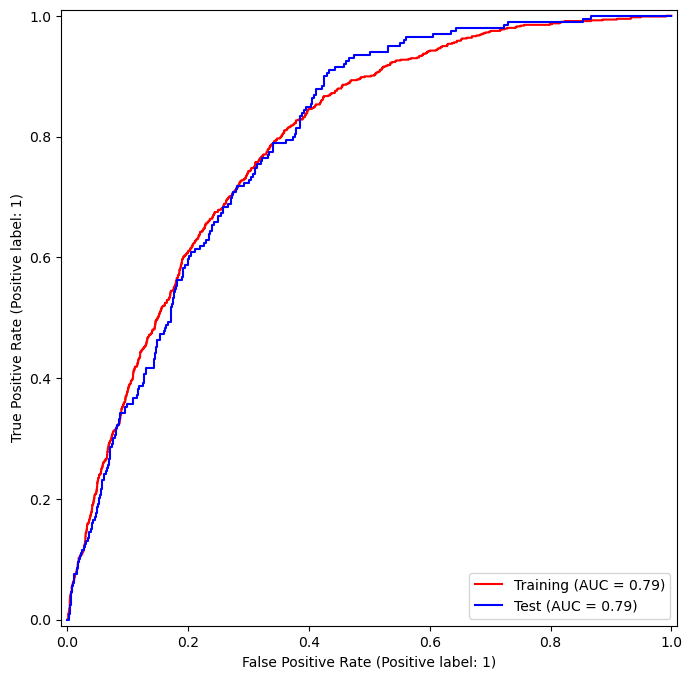

In [110]:
fig, ax = subplots(figsize=(8,8))
roc_curve(grid_poly,
          X_train,
          y_train,
          name='Training',
          color='r',
          ax=ax);
roc_curve(grid_poly,
          X_test,
          y_test,
          name='Test',
          color='b',
          ax=ax);

The code below generates a support vector classifier examining only two predictors (age and BMI) to visualize the decision boundary and margins used by the polynomial kernel model. 

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


KeyError: '[0, 5, 9, 11, 13, 14, 19, 20, 21, 22, 25, 26, 27, 28, 29, 30, 31, 34, 36, 38, 40, 41, 43, 46, 48, 51, 52, 59, 64, 67, 68, 71, 73, 76, 80, 82, 83, 84, 87, 89, 91, 94, 100, 101, 102, 103, 105, 108, 110, 111, 116, 117, 121, 124, 126, 129, 132, 135, 137, 143, 144, 148, 150, 158, 161, 162, 164, 166, 168, 172, 173, 174, 175, 177, 180, 181, 183, 192, 193, 195, 199, 200, 202, 205, 206, 207, 209, 212, 213, 223, 225, 226, 228, 231, 232, 233, 234, 235, 236, 237, 239, 240, 249, 252, 254, 255, 256, 258, 259, 263, 265, 266, 267, 268, 273, 275, 277, 280, 292, 295, 297, 299, 302, 303, 304, 305, 306, 308, 311, 312, 313, 319, 327, 329, 330, 331, 332, 334, 336, 337, 338, 341, 345, 347, 348, 349, 350, 356, 359, 360, 361, 363, 366, 371, 377, 378, 379, 380, 381, 384, 390, 392, 394, 395, 397, 401, 403, 404, 406, 410, 411, 415, 416, 417, 419, 421, 425, 428, 430, 432, 436, 438, 439, 440, 441, 442, 444, 447, 448, 449, 451, 452, 456, 460, 463, 465, 466, 468, 469, 470, 471, 477, 478, 479, 480, 482, 484

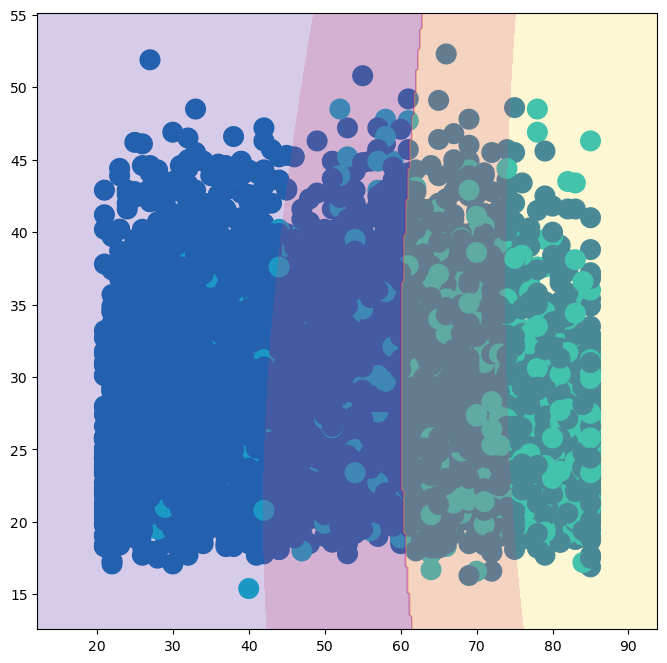

In [116]:
# 2 feature model for visualization purposes only
predictors2 = ['AGE', 'BMICALC']
X2 = health[predictors2]
y2 = health['CANCER']

svm_poly_2 = SVC(kernel='poly', 
                    class_weight='balanced',
                    C=grid_poly.best_params_['C'],
                    degree=grid_poly.best_params_['degree'])
svm_poly_2.fit(X2, y2)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X2, y2, svm_poly_2, ax=ax)
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI with Decision Boundary for Cancer Class')

The polynomial model also appears to be consistent with handling both training and test data when comparing their ROC curves. The decision boundary plot follows a similar pattern to that of the SVM with a linear kernel.

## Final Model Comparisons

| Kernel Type | Training Error Rate (pre-tuning) | Test Error Rate (pre-tuning) | Training Error Rate (post-tuning) | Test Error Rate (post-tuning) | AUC Score | Optimal Hyperparameters
|---|---|---|---|---|---|---|
| Linear | 35.14% | 34.65% | 34.78% | 33.73% | 0.79 | cost = 5 |
| Radial | 36.91% | 38.02% | 36.67% | 37.56% | 0.79 | cost = 1; gamma = 0.0001 |
| Polynomial | 30.88% | 29.70% | 32.89% | 31.82% | 0.79 | cost = 0.1; degree = 2 |

While the polynomial model achieved the lowest error rate overall, there was very minimal improvement compared to the radial and linear models. Given that their ROC curves were all very visually similar and they achieved the same AUC scores, the models likely are limited due to the predictor variables chosen, with age dominating relative to the other features. 